# CS5811 — Phase 5: Machine Learning Prediction

Primary: Random Forest. Secondary: Decision Tree. Both run twice — with and without `mental_fatigue_score` — then compared at the end.

## Setup

In [2]:
import os, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import PartialDependenceDisplay
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
os.makedirs('Output',   exist_ok=True)
os.makedirs('figures', exist_ok=True)

## Load shared splits from Phase 4

In [4]:
X_train = pd.read_csv('Output/X_train.csv')
X_test  = pd.read_csv('Output/X_test.csv')
y_train = pd.read_csv('Output/y_train.csv')['stress_cls']
y_test  = pd.read_csv('Output/y_test.csv')['stress_cls']

print('train:', X_train.shape, '| test:', X_test.shape)

train: (12000, 17) | test: (3000, 17)


## Feature sets

In [5]:
FULL        = X_train.columns.tolist()
BEHAVIOURAL = [c for c in FULL if c != 'mental_fatigue_score']

print('full:', len(FULL), '| behavioural:', len(BEHAVIOURAL))

full: 17 | behavioural: 16


---
# Random Forest — primary

### Grid search

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_grid = {
    'n_estimators':      [200],
    'max_depth':         [None, 15],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                 class_weight='balanced')
rf_gs = GridSearchCV(rf_base, rf_grid, scoring='f1_macro',
                     cv=cv, n_jobs=1, verbose=1)
rf_gs.fit(X_train[FULL], y_train)

print('best CV macro-F1:', round(rf_gs.best_score_, 4))
print('best params     :', rf_gs.best_params_)

rf_best = rf_gs.best_params_

Fitting 5 folds for each of 4 candidates, totalling 20 fits
best CV macro-F1: 0.8345
best params     : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


### Train both variants

In [7]:
def train_rf(features, label):
    m = RandomForestClassifier(**rf_best, random_state=RANDOM_STATE,
                               n_jobs=-1, class_weight='balanced')
    cv_scores = cross_val_score(m, X_train[features], y_train,
                                cv=cv, scoring='f1_macro', n_jobs=1)

    t0 = time.time()
    m.fit(X_train[features], y_train)
    fit_time = time.time() - t0

    t0 = time.time()
    p = m.predict(X_test[features])
    pred_time = time.time() - t0

    acc  = accuracy_score(y_test, p)
    prec = precision_score(y_test, p, average='macro', zero_division=0)
    rec  = recall_score(y_test, p, average='macro')
    f1m  = f1_score(y_test, p, average='macro')
    cm   = confusion_matrix(y_test, p, labels=['Low', 'Medium', 'High'])

    print(f'\n[RF · {label}]')
    print(f'  CV F1     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  accuracy  : {acc:.4f}')
    print(f'  precision : {prec:.4f}  (macro)')
    print(f'  recall    : {rec:.4f}  (macro)')
    print(f'  F1        : {f1m:.4f}  (macro)')
    print(f'  fit  time : {fit_time:.2f}s')
    print(f'  pred time : {pred_time:.4f}s')

    return m, p, {'model': 'Random Forest', 'label': label,
                  'features':       len(features),
                  'cv_f1_mean':     cv_scores.mean(),
                  'cv_f1_std':      cv_scores.std(),
                  'test_acc':       acc,
                  'test_precision': prec,
                  'test_recall':    rec,
                  'test_f1_macro':  f1m,
                  'fit_time_s':     fit_time,
                  'pred_time_s':    pred_time,
                  'cm_low':    cm[0].tolist(),
                  'cm_medium': cm[1].tolist(),
                  'cm_high':   cm[2].tolist()}

rf_full,  rf_pred_full,  rf_res_full  = train_rf(FULL,        'full')
rf_behav, rf_pred_behav, rf_res_behav = train_rf(BEHAVIOURAL, 'behavioural')


[RF · full]
  CV F1     : 0.8345 ± 0.0060
  accuracy  : 0.8907
  precision : 0.8428  (macro)
  recall    : 0.8432  (macro)
  F1        : 0.8429  (macro)
  fit  time : 0.55s
  pred time : 0.0651s

[RF · behavioural]
  CV F1     : 0.7030 ± 0.0151
  accuracy  : 0.7913
  precision : 0.6942  (macro)
  recall    : 0.6821  (macro)
  F1        : 0.6865  (macro)
  fit  time : 0.56s
  pred time : 0.0647s


### Confusion matrices

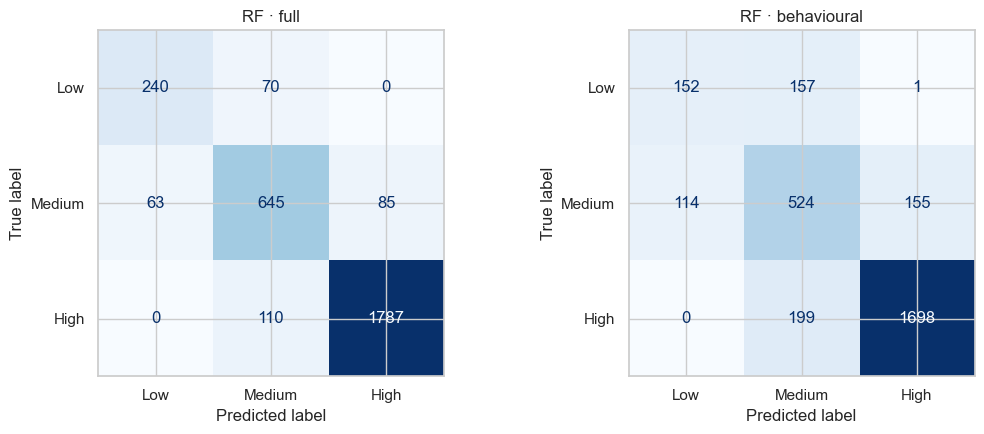

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in [(axes[0], rf_pred_full,  'RF · full'),
                        (axes[1], rf_pred_behav, 'RF · behavioural')]:
    cm = confusion_matrix(y_test, pred, labels=['Low','Medium','High'])
    ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('figures/phase5_rf_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

### Feature importance

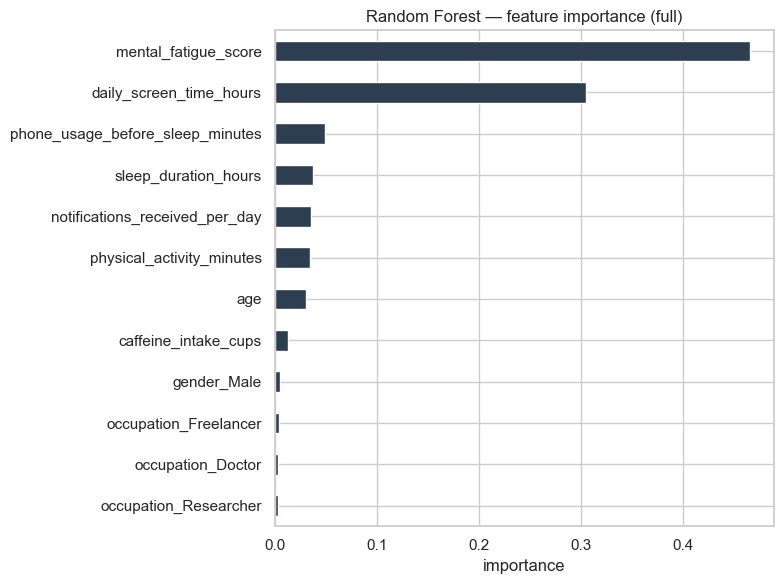

In [9]:
imp_rf = pd.Series(rf_full.feature_importances_, index=FULL).sort_values()

plt.figure(figsize=(8, 6))
imp_rf.tail(12).plot(kind='barh', color='#2c3e50')
plt.title('Random Forest — feature importance (full)')
plt.xlabel('importance')
plt.tight_layout()
plt.savefig('figures/phase5_rf_importance.png', dpi=120, bbox_inches='tight')
plt.show()

### SHAP (behavioural model)

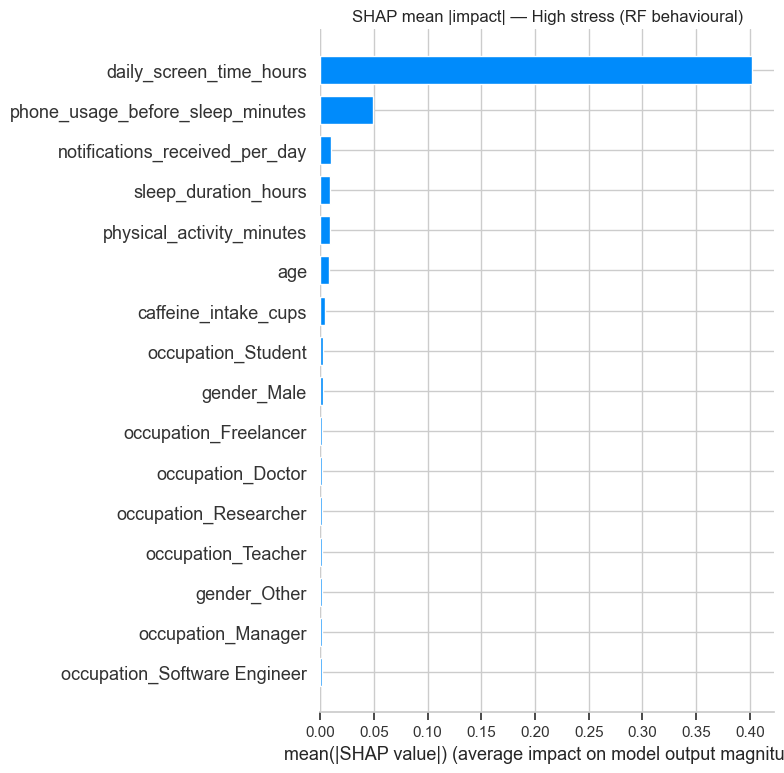

In [10]:
rng = np.random.RandomState(RANDOM_STATE)
X_shap = X_test[BEHAVIOURAL].iloc[rng.choice(len(X_test), 300, replace=False)]

explainer = shap.TreeExplainer(rf_behav)
shap_vals = explainer.shap_values(X_shap)

high_idx = ['High', 'Low', 'Medium'].index('High')

shap.summary_plot(shap_vals[:, :, high_idx], X_shap,
                  plot_type='bar', show=False)
plt.title('SHAP mean |impact| — High stress (RF behavioural)')
plt.tight_layout()
plt.savefig('figures/phase5_rf_shap.png', dpi=120, bbox_inches='tight')
plt.show()

### Partial dependence — top 3 features

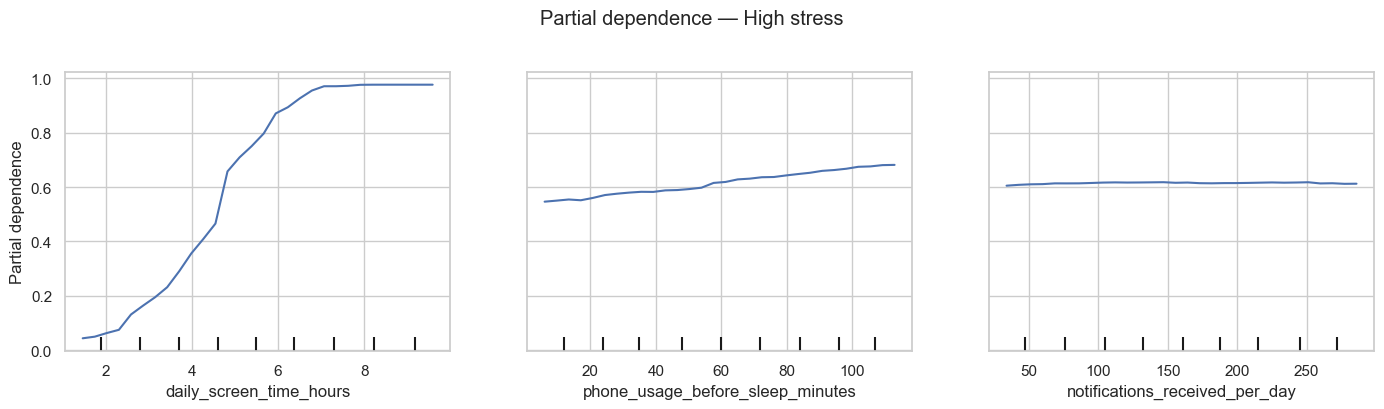

In [11]:
top3 = pd.Series(np.abs(shap_vals[:, :, high_idx]).mean(axis=0),
                 index=BEHAVIOURAL).nlargest(3).index.tolist()

fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    rf_behav, X_train[BEHAVIOURAL], features=top3,
    target='High', ax=ax, n_jobs=1, grid_resolution=30
)
plt.suptitle('Partial dependence — High stress', y=1.02)
plt.tight_layout()
plt.savefig('figures/phase5_rf_pdp.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Decision Tree — secondary

### Depth vs accuracy

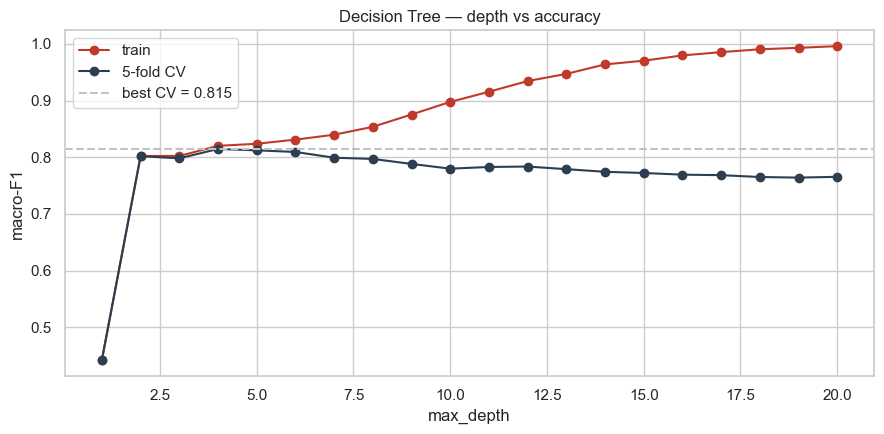

In [12]:
depths = list(range(1, 21))
train_f1, val_f1 = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE,
                               class_weight='balanced')
    m.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, m.predict(X_train), average='macro'))
    val_f1.append(cross_val_score(m, X_train, y_train, cv=cv,
                                  scoring='f1_macro', n_jobs=1).mean())

plt.figure(figsize=(9, 4.5))
plt.plot(depths, train_f1, 'o-', color='#c0392b', label='train')
plt.plot(depths, val_f1,   'o-', color='#2c3e50', label='5-fold CV')
plt.axhline(max(val_f1), linestyle='--', color='#bdc3c7',
            label=f'best CV = {max(val_f1):.3f}')
plt.xlabel('max_depth'); plt.ylabel('macro-F1')
plt.title('Decision Tree — depth vs accuracy')
plt.legend(); plt.tight_layout()
plt.savefig('figures/phase5_dt_depth.png', dpi=120, bbox_inches='tight')
plt.show()

Train F1 climbs to 1.0 while CV plateaus at depth 5 — classic overfit gap, which is why we use RF as the primary.

### Grid search

In [13]:
dt_grid = {
    'max_depth':         [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'criterion':         ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                 class_weight='balanced')
dt_gs = GridSearchCV(dt_base, dt_grid, scoring='f1_macro',
                     cv=cv, n_jobs=1, verbose=1)
dt_gs.fit(X_train[FULL], y_train)

print('best CV macro-F1:', round(dt_gs.best_score_, 4))
print('best params     :', dt_gs.best_params_)

dt_best = dt_gs.best_params_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
best CV macro-F1: 0.8168
best params     : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}


### Train both variants

In [14]:
def train_dt(features, label):
    m = DecisionTreeClassifier(**dt_best, random_state=RANDOM_STATE,
                               class_weight='balanced')
    cv_scores = cross_val_score(m, X_train[features], y_train,
                                cv=cv, scoring='f1_macro', n_jobs=1)

    t0 = time.time()
    m.fit(X_train[features], y_train)
    fit_time = time.time() - t0

    t0 = time.time()
    p = m.predict(X_test[features])
    pred_time = time.time() - t0

    acc  = accuracy_score(y_test, p)
    prec = precision_score(y_test, p, average='macro', zero_division=0)
    rec  = recall_score(y_test, p, average='macro')
    f1m  = f1_score(y_test, p, average='macro')
    cm   = confusion_matrix(y_test, p, labels=['Low', 'Medium', 'High'])

    print(f'\n[DT · {label}]')
    print(f'  CV F1     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  accuracy  : {acc:.4f}')
    print(f'  precision : {prec:.4f}  (macro)')
    print(f'  recall    : {rec:.4f}  (macro)')
    print(f'  F1        : {f1m:.4f}  (macro)')
    print(f'  fit  time : {fit_time:.2f}s')
    print(f'  pred time : {pred_time:.4f}s')
    print(f'  depth     : {m.get_depth()}  leaves: {m.get_n_leaves()}')

    return m, p, {'model': 'Decision Tree', 'label': label,
                  'features':       len(features),
                  'cv_f1_mean':     cv_scores.mean(),
                  'cv_f1_std':      cv_scores.std(),
                  'test_acc':       acc,
                  'test_precision': prec,
                  'test_recall':    rec,
                  'test_f1_macro':  f1m,
                  'fit_time_s':     fit_time,
                  'pred_time_s':    pred_time,
                  'cm_low':    cm[0].tolist(),
                  'cm_medium': cm[1].tolist(),
                  'cm_high':   cm[2].tolist()}

dt_full,  dt_pred_full,  dt_res_full  = train_dt(FULL,        'full')
dt_behav, dt_pred_behav, dt_res_behav = train_dt(BEHAVIOURAL, 'behavioural')


[DT · full]
  CV F1     : 0.8168 ± 0.0130
  accuracy  : 0.8737
  precision : 0.8118  (macro)
  recall    : 0.8561  (macro)
  F1        : 0.8313  (macro)
  fit  time : 0.10s
  pred time : 0.0051s
  depth     : 5  leaves: 32

[DT · behavioural]
  CV F1     : 0.6936 ± 0.0078
  accuracy  : 0.7577
  precision : 0.6539  (macro)
  recall    : 0.7268  (macro)
  F1        : 0.6748  (macro)
  fit  time : 0.06s
  pred time : 0.0056s
  depth     : 5  leaves: 31


### Confusion matrices

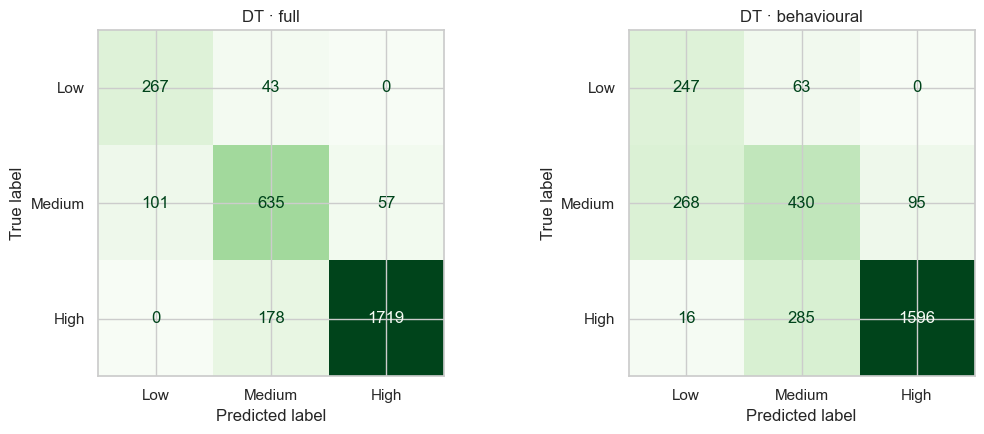

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in [(axes[0], dt_pred_full,  'DT · full'),
                        (axes[1], dt_pred_behav, 'DT · behavioural')]:
    cm = confusion_matrix(y_test, pred, labels=['Low','Medium','High'])
    ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(
        ax=ax, cmap='Greens', colorbar=False, values_format='d')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('figures/phase5_dt_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

### Tree visualisation — top 3 levels

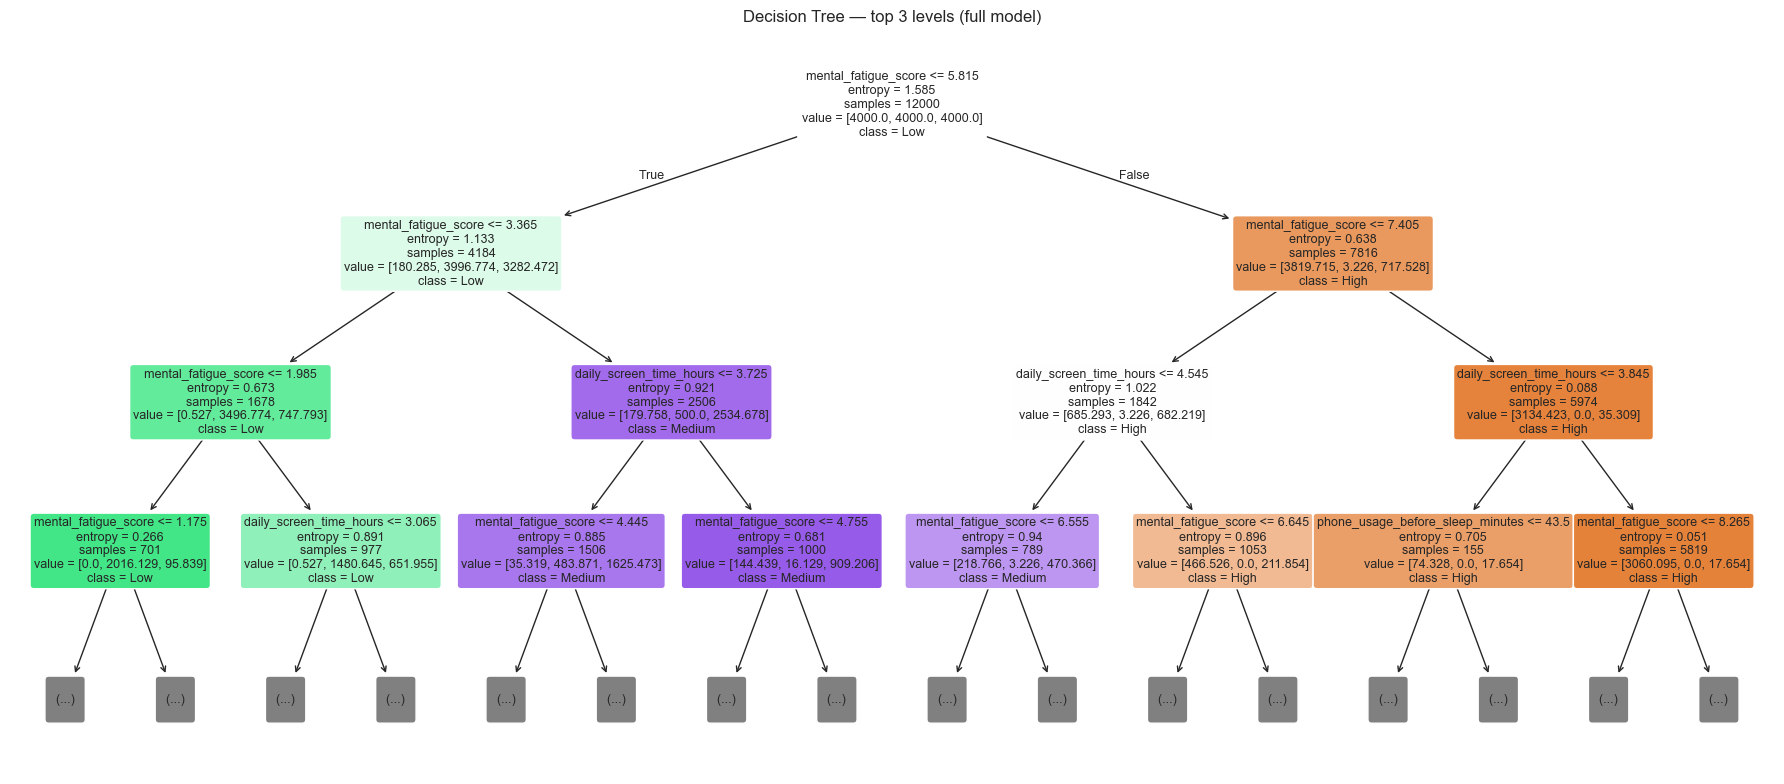

In [16]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt_full, max_depth=3, feature_names=FULL,
          class_names=['High', 'Low', 'Medium'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Decision Tree — top 3 levels (full model)')
plt.tight_layout()
plt.savefig('figures/phase5_dt_tree.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
print(export_text(dt_full, feature_names=FULL, max_depth=3))

|--- mental_fatigue_score <= 5.82
|   |--- mental_fatigue_score <= 3.36
|   |   |--- mental_fatigue_score <= 1.99
|   |   |   |--- mental_fatigue_score <= 1.17
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- mental_fatigue_score >  1.17
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- mental_fatigue_score >  1.99
|   |   |   |--- daily_screen_time_hours <= 3.06
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- daily_screen_time_hours >  3.06
|   |   |   |   |--- truncated branch of depth 2
|   |--- mental_fatigue_score >  3.36
|   |   |--- daily_screen_time_hours <= 3.73
|   |   |   |--- mental_fatigue_score <= 4.44
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- mental_fatigue_score >  4.44
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- daily_screen_time_hours >  3.73
|   |   |   |--- mental_fatigue_score <= 4.76
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- mental_fatigue_score >  4.76

---
# Comparison — Random Forest vs Decision Tree

### Combined metrics

In [18]:
results = pd.DataFrame([rf_res_full, rf_res_behav,
                        dt_res_full, dt_res_behav])
results.round(4)

,model,label,features,cv_f1_mean,cv_f1_std,test_acc,test_precision,test_recall,test_f1_macro,fit_time_s,pred_time_s,cm_low,cm_medium,cm_high
0,Random Forest,full,17,0.8345,0.0060,0.8907,0.8428,0.8432,0.8429,0.5550,0.0651,"[240, 70, 0]","[63, 645, 85]","[0, 110, 1787]"
1,Random Forest,behavioural,16,0.7030,0.0151,0.7913,0.6942,0.6821,0.6865,0.5561,0.0647,"[152, 157, 1]","[114, 524, 155]","[0, 199, 1698]"
2,Decision Tree,full,17,0.8168,0.0130,0.8737,0.8118,0.8561,0.8313,0.1027,0.0051,"[267, 43, 0]","[101, 635, 57]","[0, 178, 1719]"
3,Decision Tree,behavioural,16,0.6936,0.0078,0.7577,0.6539,0.7268,0.6748,0.0574,0.0056,"[247, 63, 0]","[268, 430, 95]","[16, 285, 1596]"


### Accuracy and F1 side by side

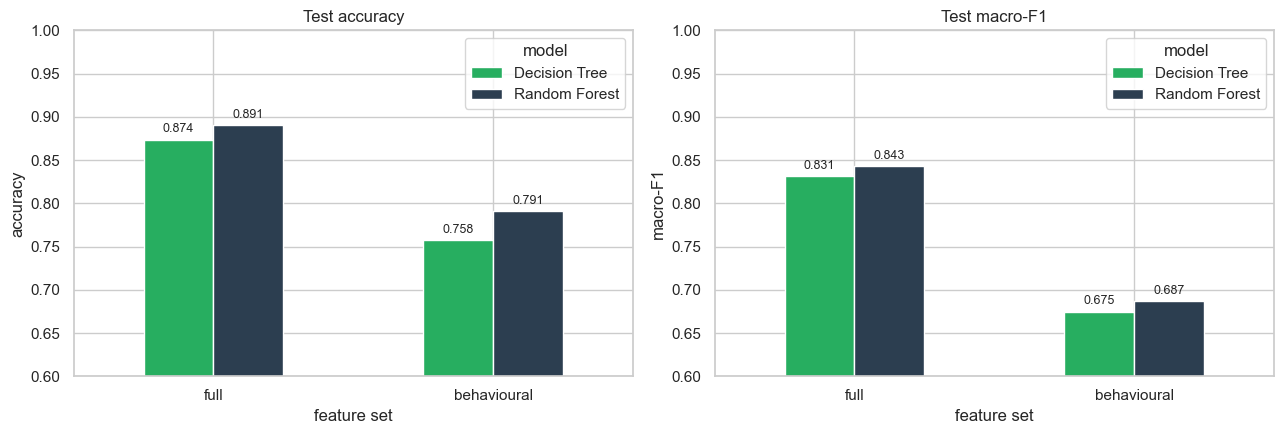

In [19]:
pivot = results.pivot(index='label', columns='model',
                      values=['test_acc', 'test_f1_macro']).reindex(['full', 'behavioural'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pivot['test_acc'].plot(kind='bar', ax=axes[0],
                      color=['#27ae60', '#2c3e50'], rot=0, edgecolor='white')
axes[0].set_title('Test accuracy'); axes[0].set_xlabel('feature set')
axes[0].set_ylabel('accuracy'); axes[0].set_ylim([0.6, 1.0])
axes[0].legend(title='model')
for c in axes[0].containers: axes[0].bar_label(c, fmt='%.3f', padding=3, fontsize=9)

pivot['test_f1_macro'].plot(kind='bar', ax=axes[1],
                            color=['#27ae60', '#2c3e50'], rot=0, edgecolor='white')
axes[1].set_title('Test macro-F1'); axes[1].set_xlabel('feature set')
axes[1].set_ylabel('macro-F1'); axes[1].set_ylim([0.6, 1.0])
axes[1].legend(title='model')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('figures/phase5_rf_vs_dt_bars.png', dpi=120, bbox_inches='tight')
plt.show()

### Ensembling gain (RF − DT)

In [20]:
gains = []
for fs in ['full', 'behavioural']:
    rf_acc = results.query("model=='Random Forest' and label==@fs")['test_acc'].iloc[0]
    dt_acc = results.query("model=='Decision Tree' and label==@fs")['test_acc'].iloc[0]
    rf_f1  = results.query("model=='Random Forest' and label==@fs")['test_f1_macro'].iloc[0]
    dt_f1  = results.query("model=='Decision Tree' and label==@fs")['test_f1_macro'].iloc[0]
    gains.append({'feature_set': fs,
                  'DT_acc':  round(dt_acc, 4), 'RF_acc':  round(rf_acc, 4),
                  'acc_gain_pts': round((rf_acc - dt_acc) * 100, 2),
                  'DT_f1':   round(dt_f1,  4), 'RF_f1':   round(rf_f1,  4),
                  'f1_gain_pts':  round((rf_f1  - dt_f1)  * 100, 2)})

gain_df = pd.DataFrame(gains)
gain_df

,feature_set,DT_acc,RF_acc,acc_gain_pts,DT_f1,RF_f1,f1_gain_pts
0,full,0.8737,0.8907,1.70,0.8313,0.8429,1.16
1,behavioural,0.7577,0.7913,3.37,0.6748,0.6865,1.17


Ensembling gain is larger on the behavioural set — RF earns more accuracy when the easy leakage feature is gone.

### Feature importance agreement

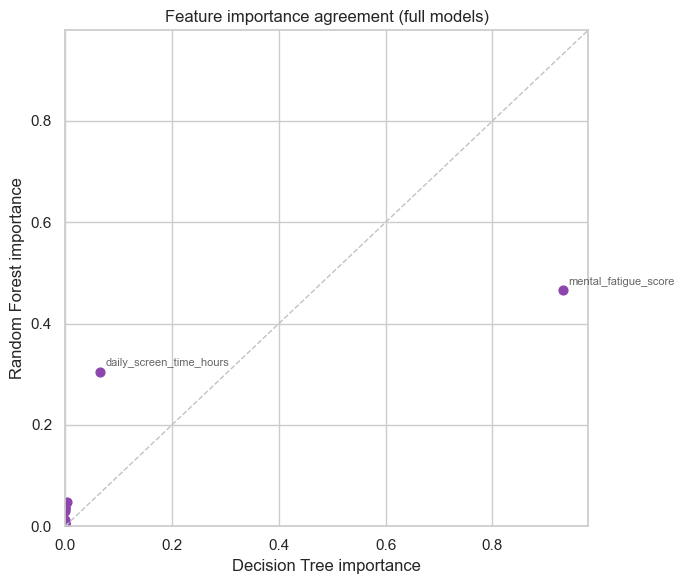

Spearman rank correlation: 0.665


In [21]:
agreement = pd.DataFrame({
    'DT': dt_full.feature_importances_,
    'RF': rf_full.feature_importances_
}, index=FULL).sort_values('RF', ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(agreement['DT'], agreement['RF'], s=40, color='#8e44ad')
for name, r in agreement.iterrows():
    if r['RF'] > 0.05 or r['DT'] > 0.05:
        ax.annotate(name, (r['DT'], r['RF']), fontsize=8, alpha=0.7,
                    xytext=(4, 4), textcoords='offset points')
lim = max(agreement.values.max() * 1.05, 0.6)
ax.plot([0, lim], [0, lim], '--', color='#bdc3c7', linewidth=1)
ax.set_xlim([0, lim]); ax.set_ylim([0, lim])
ax.set_xlabel('Decision Tree importance'); ax.set_ylabel('Random Forest importance')
ax.set_title('Feature importance agreement (full models)')
plt.tight_layout()
plt.savefig('figures/phase5_rf_dt_importance_agreement.png', dpi=120, bbox_inches='tight')
plt.show()

print('Spearman rank correlation:',
      round(agreement.corr(method='spearman').iloc[0, 1], 3))

Points on the diagonal = models agree on feature ranking. Convergent evidence for which features drive stress.

### Which model wins

In [22]:
verdict = []
for fs in ['full', 'behavioural']:
    rf_f1 = results.query("model=='Random Forest' and label==@fs")['test_f1_macro'].iloc[0]
    dt_f1 = results.query("model=='Decision Tree' and label==@fs")['test_f1_macro'].iloc[0]
    winner = 'Random Forest' if rf_f1 > dt_f1 else 'Decision Tree'
    verdict.append({'feature_set': fs, 'winner': winner,
                    'f1_gap_pts': round(abs(rf_f1 - dt_f1) * 100, 2)})

pd.DataFrame(verdict)

,feature_set,winner,f1_gap_pts
0,full,Random Forest,1.16
1,behavioural,Random Forest,1.17


Random Forest wins on both, with a larger gap on the behavioural set. Ensembling earns more accuracy when the signal is harder.

## Save results

In [23]:
results.to_csv('Output/ml_metrics.csv', index=False)
gain_df.to_csv('Output/rf_vs_dt_gain.csv', index=False)
agreement.to_csv('Output/feature_importance_agreement.csv')

joblib.dump(rf_full,  'Output/rf_full.pkl')
joblib.dump(rf_behav, 'Output/rf_behavioural.pkl')
joblib.dump(dt_full,  'Output/dt_full.pkl')
joblib.dump(dt_behav, 'Output/dt_behavioural.pkl')

pd.DataFrame({
    'y_true':        y_test.values,
    'rf_pred_full':  rf_pred_full,
    'rf_pred_behav': rf_pred_behav,
    'dt_pred_full':  dt_pred_full,
    'dt_pred_behav': dt_pred_behav
}).to_csv('Output/ml_predictions.csv', index=False)

print('Saved:')
for f in sorted(os.listdir('Output')):
    if any(k in f for k in ['ml_', 'rf_', 'dt_', 'feature_importance_agreement']):
        print(' -', f)

Saved:
 - dt_behavioural.pkl
 - dt_full.pkl
 - feature_importance_agreement.csv
 - ml_metrics.csv
 - ml_predictions.csv
 - rf_behavioural.pkl
 - rf_full.pkl
 - rf_vs_dt_gain.csv


---
## Team comparison export

Single CSV containing all six metrics for every method × feature-set combination — the file format the team agreed for Section 6 cross-comparison.

In [24]:
def cm_to_string(cm_low, cm_medium, cm_high):
    """Flatten the 3×3 confusion matrix into a single readable string."""
    rows = [cm_low, cm_medium, cm_high]
    return ' | '.join(','.join(str(v) for v in r) for r in rows)

team_rows = []
for r in [rf_res_full, rf_res_behav, dt_res_full, dt_res_behav]:
    team_rows.append({
        'member':           'Gaurav',
        'method':           r['model'],
        'feature_set':      r['label'],
        'n_features':       r['features'],
        'accuracy':         round(r['test_acc'], 4),
        'precision_macro':  round(r['test_precision'], 4),
        'recall_macro':     round(r['test_recall'], 4),
        'f1_macro':         round(r['test_f1_macro'], 4),
        'cv_f1_mean':       round(r['cv_f1_mean'], 4),
        'cv_f1_std':        round(r['cv_f1_std'], 4),
        'fit_time_s':       round(r['fit_time_s'], 3),
        'pred_time_s':      round(r['pred_time_s'], 4),
        'confusion_matrix': cm_to_string(r['cm_low'], r['cm_medium'], r['cm_high']),
    })

team_df = pd.DataFrame(team_rows)
team_df.to_csv('Output/team_comparison_export.csv', index=False)

print('Wrote Output/team_comparison_export.csv')
team_df

Wrote Output/team_comparison_export.csv


,member,method,feature_set,n_features,accuracy,precision_macro,recall_macro,f1_macro,cv_f1_mean,cv_f1_std,fit_time_s,pred_time_s,confusion_matrix
0,Gaurav,Random Forest,full,17,0.8907,0.8428,0.8432,0.8429,0.8345,0.0060,0.555,0.0651,"240,70,0 | 63,645,85 | 0,110,1787"
1,Gaurav,Random Forest,behavioural,16,0.7913,0.6942,0.6821,0.6865,0.7030,0.0151,0.556,0.0647,"152,157,1 | 114,524,155 | 0,199,1698"
2,Gaurav,Decision Tree,full,17,0.8737,0.8118,0.8561,0.8313,0.8168,0.0130,0.103,0.0051,"267,43,0 | 101,635,57 | 0,178,1719"
3,Gaurav,Decision Tree,behavioural,16,0.7577,0.6539,0.7268,0.6748,0.6936,0.0078,0.057,0.0056,"247,63,0 | 268,430,95 | 16,285,1596"


**Format of the `confusion_matrix` column:** rows separated by `|`, cells separated by `,`. Order is rows = true labels (Low / Medium / High), columns = predicted labels (Low / Medium / High).

Example: `240,70,0 | 63,645,85 | 0,110,1787` reads as: 240 true-Low predicted Low, 70 true-Low predicted Medium, 0 true-Low predicted High, etc.

This single-cell encoding keeps the CSV flat (one row per model × feature-set combination) so teammates can simply concatenate everyone's exports into a comparison table.